# Hypothesis testing and evaluation

## EXERCISE: Comparing layouts

### Experimental setup

*Problem*: Find out which version of a display is better.

*Question*: Do users prefer Grid view?

*Null hypothesis*: Users do not prefer Grid view.

### Create ratings data

We assume different subject groups for each conditions. Each subject sees one of the layouts and is asked to rate on a 5-point Likert scale how strongly the agree or disagree with the statement:

> Page gives a good overview.
>
> 1=strongly agree; 2=agree; 3=neutral; 4=disagree; 5=strongly disagree

G_data corresponds to ratings from users that see the grid view. L_data corresponds to ratings from users that see the list view.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from collections import Counter
from typing import Iterable

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)

In [4]:
G_data = [
  1, 3, 3, 2, 4, 2, 3, 3, 1, 5, 2, 3, 4, 2, 1, 3, 2, 2, 1, 3,
  2, 3, 4, 2, 1, 3, 2, 2, 1, 3, 1, 3, 3, 2, 4, 2, 3, 3, 1, 5
]

L_data = [
  4, 5, 2, 4, 4, 3, 5, 4, 3, 5, 1, 4, 5, 3, 4, 4, 2, 3, 4, 5,
  1, 4, 5, 3, 4, 4, 2, 3, 4, 5, 4, 5, 2, 4, 4, 3, 5, 4, 3, 5
]

print('Grid median:', np.median(G_data))
print('List median:', np.median(L_data))

Grid median: 2.5
List median: 4.0


### Visualise ratings data

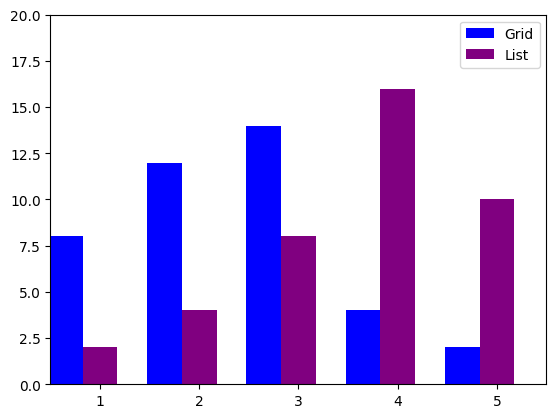

In [5]:
%matplotlib inline
def count(data):
  c = Counter(data)
  return list(c.keys()), list(c.values())

G_bins, G_freqs = count(G_data)
L_bins, L_freqs = count(L_data)
bar_width = 0.35

_ = plt.bar([b-bar_width for b in G_bins], G_freqs, bar_width, color='blue', label='Grid')
_ = plt.bar(L_bins, L_freqs, bar_width, color='purple', label='List')

plt.xlim(0.5, 5.5)
plt.ylim(0,20)
_ = plt.legend()

### TODO Test whether list is preferred

- Can we reject the null hypothesis at p<0.01 using the Mann-Whitney U test?
- Do users prefer list view?

In [6]:
p_value = stats.mannwhitneyu(G_data, L_data).pvalue
print("Pvalue = ", p_value)
print("Pvalue <1%: ", p_value < 0.01)

if p_value < 0.01:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")

Pvalue =  1.0962183338899868e-05
Pvalue <1%:  True
Reject null hypothesis


### TODO p-hacking example

Imagine we instead measured average monthly spend. Let's assume a sample of 1000 grid users spend \$155 on average with standard deviation 40, and a sample of 1000 list users spend \$150 on average with standard deviation 40.

In [7]:
N = 1000
G_mu, G_sigma = 155, 40
L_mu, L_sigma = 150, 40

In [8]:
def run_experiment():
  G_spend = np.random.normal(G_mu, G_sigma, N)
  L_spend = np.random.normal(L_mu, L_sigma, N)

  return stats.ttest_ind(G_spend, L_spend).pvalue*0.5 # one-tailed for testing G_mu > L_mu

- Run 1000 experiments
- For what percentage of experiments do we fail to reject the null hypothesis at 0.05?
- Do your neighbours get the same percentage?
- How can we avoid false rejections?

In [9]:
# To avoid type 1 errors, we can run multiple experiments and calculate the proportion of fails.
# To increase the feasibility of the experiment, we can increase the number of experiments or 
# the sample size.

number_fails = 0
number_experiments = 1000

for experiment in range(number_experiments):
  p_value = run_experiment()
  if p_value > 0.05:
    number_fails += 1

print(f"The number of fails in this experiemnt was {number_fails} out of {number_experiments} experiments")
print(f"Type 1 Error proportion is: {number_fails/number_experiments}")

The number of fails in this experiemnt was 120 out of 1000 experiments
Type 1 Error proportion is: 0.12


## *STOP PLEASE. THE FOLLOWING IS FOR THE NEXT EXERCISE. THANKS.*

## EXERCISE: Comparing mobile behaviour

### Experimental setup

Adapted from http://www.beefissuesquarterly.com/beefissuesquarterly.aspx?id=4078.

*Problem*: Find out whether there is a difference in mobile behaviour between generations.

*Question*: Is there any difference between groups?

*Null hypothesis*: Group means are the same.

### Generate generation data

Imagine we conducted a survey of 200 baby boomers (born 1945-1960), 200 generation xers (born 1961-1980) and 200 millennials (born 1981-1995).

For the purposes of this exercise, let's generate some simulated samples. We assume:
- Boomers send 5 texts per day on average with standard deviation 2;
- GenXers send 12 texts per day on average with standard deviation 3;
- Millennials send 20 texts per day on average with standard deviation 5.

We use `numpy.random.normal` to generate random values from a normal distribution with these parameters

In [10]:
import numpy as np
N = 200
B_mu, B_sigma = 5, 2
X_mu, X_sigma = 12, 3
M_mu, M_sigma = 20, 5
B_data = [int(round(n)) for n in np.random.normal(B_mu, B_sigma, N)]
X_data = [int(round(n)) for n in np.random.normal(X_mu, X_sigma, N)]
M_data = [int(round(n)) for n in np.random.normal(M_mu, M_sigma, N)]

### Visualise generation data

Let's use the `matplotlib.pyplot.hist` function to plot our visualise our three distributions.

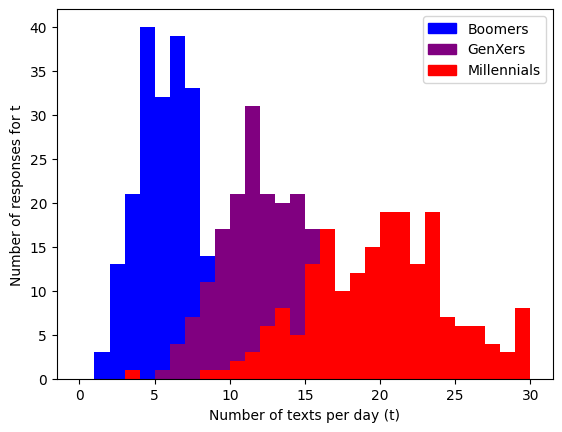

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
start,end,n_bins = 0,30,30
_,_,_ = plt.hist(B_data, bins=n_bins, range=(start,end), color='blue')
_,_,_ = plt.hist(X_data, bins=n_bins, range=(start,end), color='purple')
_,_,_ = plt.hist(M_data, bins=n_bins, range=(start,end), color='red')
_ = plt.legend(handles=[mpatches.Patch(color='blue', label='Boomers'),
                    mpatches.Patch(color='purple', label='GenXers'),
                    mpatches.Patch(color='red', label='Millennials')])
_ = plt.xlabel('Number of texts per day (t)')
_ = plt.ylabel('Number of responses for t')

### TODO Test for differences

- Use one-way analysis of variance (ANOVA) to test whether the sample means are the same.
- Can we reject the null hypothesis at p<0.01?
- Is there a reliable difference in texting behaviour between generations?

In [13]:
confidence = 0.01
percentage = (1.00 - confidence)*100

anova_result = stats.f_oneway(B_data, X_data, M_data)
# print(bool(anova_result.pvalue < 0.01))

message_conf = f'with a confidence of {percentage:.2f}%, '
message_1 = message_conf + 'there is statistical evidence that there are differences in texting behaviour between generations groups'
message_2 = message_conf + 'there is NO statistical evidence that there are differences in texting behaviour between generations groups'

if bool(anova_result.pvalue < 0.01):
    print(message_1)
else:
    print(message_2) 

with a confidence of 99.00%, there is statistical evidence that there are differences in texting behaviour between generations groups


### TODO Check ANOVA assumptions

- Does our data meet the assumptions for a one-way ANOVA?
- Can we reject the null hypothesis using the Kruskall-Wallis H-test?
- Is there a reliable difference in texting behaviour between generations?

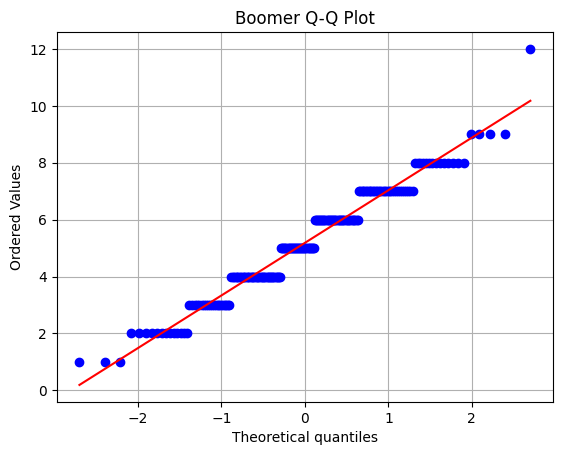

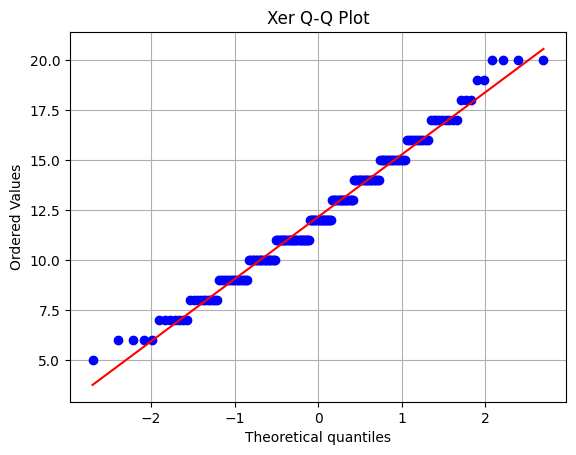

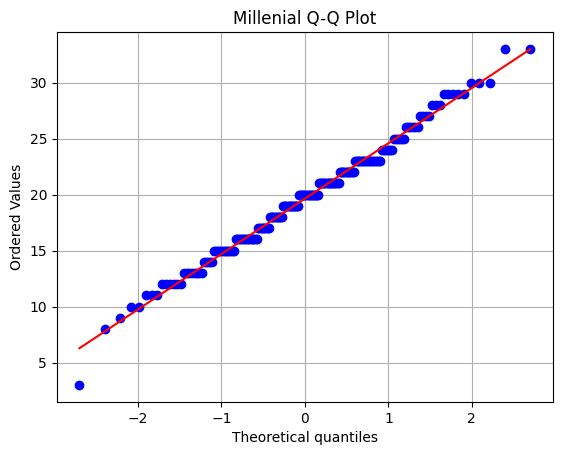

Because the sample is large (N > 50), we shall use the Kolmogorv-Smirnov test assert normality of data dependant variables

pvalue for Boomer  data is: 0.0038912861903705066
with a confidence of 95.00%, there is statistical evidence that allow us to reject H0
pvalue for Xer  data is: 0.02187531148666661
with a confidence of 95.00%, there is statistical evidence that allow us to reject H0
pvalue for Millenial  data is: 0.31807923741196464
with a confidence of 95.00%, there is NO statistical evidence that allow us to reject H0

----------------------
with a confidence of 99.00%, there is statistical evidence that there is any difference in texting behaviour between generations groups

----------------------
with a confidence of 95.00%, Kruskall-Wallis H-test suggest there is statistical evidence that allow us to reject H0

----------------------
As one of the one-way ANOVA assumpions (all the samples are nomrally distributed) is barely meet and the olther assumption is nor (heterocesatoc

In [30]:
def plot_qq(data: Iterable, title='Q-Q Plot') -> None:
    """
    Generates a Q-Q plot for a single sample to check for normality.
    """
    stats.probplot(data, dist = 'norm', plot = plt)
    plt.title(title)
    plt.grid(True)
    plt.show()

samples = [B_data, X_data, M_data]
names = ['Boomer ', 'Xer ', 'Millenial ']

for data, title in zip(samples, names):
    plot_qq(data, title + 'Q-Q Plot')

print('Because the sample is large (N > 50), we shall use the Kolmogorv-Smirnov test assert normality of data dependant variables\n')

confidence = 0.05

message_conf = f'with a confidence of {(1.00 - confidence)*100:.2f}%, '
message_1 = message_conf + 'there is statistical evidence that allow us to reject H0'
message_2 = message_conf + 'there is NO statistical evidence that allow us to reject H0'

pvalues_kstest = []
for data, name in zip(samples, names):
    _, pvalue_kstest = stats.kstest((data - np.mean(data))/np.std(data, ddof = 1), 'norm', alternative = 'two-sided')
    pvalues_kstest.append(pvalue_kstest)
    print(f'pvalue for {name} data is: {pvalue_kstest}')
    
    if bool(pvalue_kstest < confidence):
        print(message_1)
    else:
        print(message_2)

print('\n----------------------')

# Even in there is statistical evidence that allow us to reject normality hypotesis for Boomer data, 
# the QQ plot show us that it is still fair to consider the sample as normally distributes although some
# outliers. Thus, we shall test the sample's variance homogeneity using the Levenne's test:
_, bartlett_pvalue = stats.bartlett([float(val) for val in B_data], [float(val) for val in X_data], [float(val) for val in M_data])

message_conf = f'with a confidence of {percentage:.2f}%, '
message_1 = message_conf + 'there is statistical evidence that there is any difference in texting behaviour between generations groups'
message_2 = message_conf + 'there is NO statistical evidence that there is any difference in texting behaviour between generations groups'

if bool(anova_result.pvalue < 0.01):
    print(message_1)
else:
    print(message_2) 

print('\n----------------------')

# TODO - Implement the other test
_, pvalue_kruskal = stats.kruskal(B_data, X_data, M_data)

message_conf = f'with a confidence of {(1.00 - confidence)*100:.2f}%, '
message_1 = message_conf + 'Kruskall-Wallis H-test suggest there is statistical evidence that allow us to reject H0'
message_2 = message_conf + 'Kruskall-Wallis H-test suggest there is NO statistical evidence that allow us to reject H0'

if bool(pvalue_kruskal < confidence):
    print(message_1)
else:
    print(message_2)

print('\n----------------------')
print('As one of the one-way ANOVA assumpions (all the samples are nomrally distributed) is barely meet and the olther assumption is nor (heterocesatocity), we should not use the one-way ANOVA as a test for our group.')

### TODO Further generation exercises

Imagine we wanted to compare millennials to generation z (born since 1996). Let's assume this population sends 21 texts per day on average with standard deviation 5.

- Generate a simulated sample Z_data.
- What test should we use?
- Is there a reliable difference in texting behaviour between millennials and generation Z?

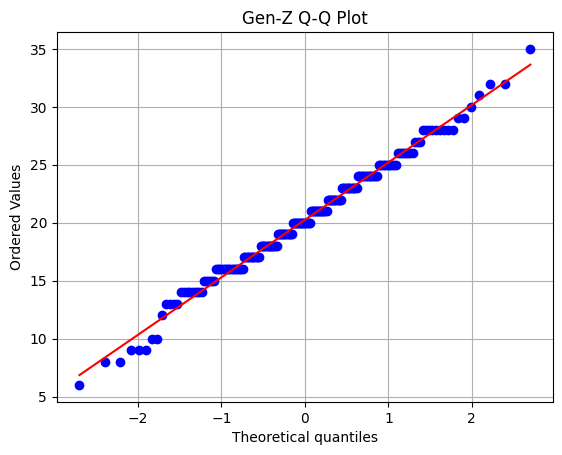

With a confidence of 95.00%, Kolmogorov-Smirnov test suggest there is statistical evidence that allow us to reject H0
With a confidence of 95.00%, Kolmogorov-Smirnov test suggest there is statistical evidence that allow us to reject H0

----------------------
With a confidence of 95.00%, Bartlett test suggest there is NO statistical evidence that allow us to reject H0. Thus, it is reasonable to think both samples have EQUAL variances

----------------------
With a confidence of 95.00%, Parametric one-way ANOVE test suggest there is NO statistical evidence that allow us to reject H0. Thus, it is reasonable to think both samples have EQUAL mean values


In [36]:
Z_mu, Z_sigma = 21, 5
Z_data = [int(round(n)) for n in np.random.normal(Z_mu, Z_sigma, N)]

plot_qq(Z_data, 'Gen-Z Q-Q Plot')

_, M_pvalue_kstest = stats.kstest((M_data - np.mean(M_data))/np.std(M_data, ddof = 1), 'norm', alternative = 'two-sided')
_, Z_pvalue_kstest = stats.kstest((Z_data - np.mean(Z_data))/np.std(Z_data, ddof = 1), 'norm', alternative = 'two-sided')

message_conf = f'With a confidence of {(1.00 - confidence)*100:.2f}%, '
message_1 = message_conf + 'Kolmogorov-Smirnov test suggest there is statistical evidence that allow us to reject H0'
message_2 = message_conf + 'Kolmogorov-Smirnov test suggest there is NO statistical evidence that allow us to reject H0'

for values in M_pvalue_kstest, Z_pvalue_kstest:
    if bool(pvalue_kruskal < confidence):
        print(message_1)
    else:
        print(message_2)

print('\n----------------------')
# According with the results, there is statistical evidence allowing us to consider H0 for both samples. Thus, now we know both samples are normally distributed, we can use the Bartlett test to test homocecasticity.

_, bartlett_pvalue = stats.bartlett([float(val) for val in M_data], [float(val) for val in Z_data])

message_1 = message_conf + 'Bartlett test suggest there is statistical evidence that allow us to reject H0. Thus, it is reasonable to think both samples have DIFFERENT variances'
message_2 = message_conf + 'Bartlett test suggest there is NO statistical evidence that allow us to reject H0. Thus, it is reasonable to think both samples have EQUAL variances'

if bool(bartlett_pvalue < confidence):
    print(message_1)
else:
    print(message_2)

print('\n----------------------')
# According with the results, there is statistical evidence allowing us to consider H0 for both samples, which implies that both have the same variance. Therefore, we caoun now use a one-way ANOVA to check is both samples come from different mean distributions as every assumption is met.

_, anova_pvalue = stats.f_oneway(M_data, Z_data)

message_1 = message_conf + 'Parametric one-way ANOVE test suggest there is statistical evidence that allow us to reject H0. Thus, it is reasonable to think both samples have DIFFERENT mean values'
message_2 = message_conf + 'Parametric one-way ANOVE test suggest there is NO statistical evidence that allow us to reject H0. Thus, it is reasonable to think both samples have EQUAL mean values'

if bool(bartlett_pvalue < confidence):
    print(message_1)
else:
    print(message_2)

## *STOP PLEASE. THE FOLLOWING IS FOR THE NEXT EXERCISE. THANKS.*

## EXERCISE: Comparing classifiers

### Experimental setup

*Problem*: Determine which classifer is better.

*Question*: Is my shiny, new model better?

*Null hypothesis*: The new model is not better.

### Generate gold and classifier labellings

We generate 10,000 gold labels, marking a approximately 20% as spam (1) based on a random number generator and the rest as ham (0).

In [37]:
import random
random.random()
N = 10000
GOLD_PCT_SPAM = 0.2
Y_gold = [int(random.random()<GOLD_PCT_SPAM) for _ in range(N)]

freq = Counter(Y_gold)
print (freq)

Counter({0: 8000, 1: 2000})


We generate two system labellings by ranodomly flipping gold labels assuming:
- System 1 incorrectly marks 5% of ham as spam and fails to detect 20% of actual spam,
- System 2 incorrectly marks 10% of ham as spam and fails to detect 10% of actual spam.

In [ ]:
SYS1_ERROR_RATES = {
    0: 0.05,  # spurious: sys1 incorrectly marks 5% of ham as spam
    1: 0.2,   # misses: sys1 fails to detect 20% of spam
}
SYS2_ERROR_RATES = {
    0: 0.1,  # spurious: sys2 incorrectly marks 10% of ham as spam
    1: 0.1   # misses: sys2 fails to detect 10% of spam
}

def simulate_predictions(Yg, error_rates):
    for y in Yg:
        if random.random()<error_rates[y]:
            yield 1-y
        else:
            yield y

Y_sys1 = list(simulate_predictions(Y_gold, SYS1_ERROR_RATES))
Y_sys2 = list(simulate_predictions(Y_gold, SYS2_ERROR_RATES))

y_actu = pd.Series(Y_gold, name='Actual')
y_pred_s1 = pd.Series(Y_sys1, name='Predicted')
y_pred_s2 = pd.Series(Y_sys2, name='Predicted')

confusion_s1 = pd.crosstab(y_actu,y_pred_s1)
print(confusion_s1)
print()
confusion_s2 = pd.crosstab(y_actu, y_pred_s2)
print(confusion_s2)

Predicted     0     1
Actual               
0          7604   396
1           415  1585

Predicted     0     1
Actual               
0          7195   805
1           226  1774


### Split data into folds

In [44]:
NUM_FOLDS = 10

Y_gold_folds = np.array_split(Y_gold, NUM_FOLDS)
Y_sys1_folds = np.array_split(Y_sys1, NUM_FOLDS)
Y_sys2_folds = np.array_split(Y_sys2, NUM_FOLDS)

freq = Counter(Y_gold_folds[0])
print (freq)
freq = Counter(Y_sys1_folds[0])
print (freq)
freq = Counter(Y_sys2_folds[0])
print (freq)

Counter({np.int64(0): 794, np.int64(1): 206})
Counter({np.int64(0): 793, np.int64(1): 207})
Counter({np.int64(0): 734, np.int64(1): 266})


### TODO Calculating classifier accuracy

- Calculate accuracy and f1 scores on first fold.
- Which system has higher accuracy?
- Which system has higher f1 score?
- Which measure has better sensitivity for comparisons?
- Which measure would you rather report?

In [45]:
PRF_KWARGS = {
    'pos_label': 1,     # 1 is the positive spam label
    'average': 'binary' # evaluate p/r/f of the positive label
}

Yg0 = Y_gold_folds[0]
Y10 = Y_sys1_folds[0]
Y20 = Y_sys2_folds[0]

y_actu = pd.Series(Yg0, name='Actual')
y_pred_s1 = pd.Series(Y10, name='Predicted')
y_pred_s2 = pd.Series(Y20, name='Predicted')
confusion_s1 = pd.crosstab(y_actu ,y_pred_s1 )
print(confusion_s1)
print()
confusion_s2 = pd.crosstab(y_actu, y_pred_s2 )
print(confusion_s2)

print("System 1 accuracy:", accuracy_score(Yg0, Y10))
print("System 2 accuracy:", accuracy_score(Yg0, Y20))
print("System 1 f1 score:", f1_score(Yg0, Y10, **PRF_KWARGS))
print("System 2 f1 score:", f1_score(Yg0, Y20, **PRF_KWARGS))

Predicted    0    1
Actual             
0          753   41
1           40  166

Predicted    0    1
Actual             
0          711   83
1           23  183
System 1 accuracy: 0.919
System 2 accuracy: 0.894
System 1 f1 score: 0.8038740920096852
System 2 f1 score: 0.7754237288135594


- Calculate precision and recall scores on first fold.
- Which system has higher precision?
- Which system has higher recall?
- Formulate precision and recall in terms GOLD_PCT_SPAM, SPURIOUS_ERROR_RATE and MISSED_ERROR_RATE
- Are precision and recall values as expected?

In [47]:
len(Y_gold_folds)

10

In [ ]:
Yg0 = Y_gold_folds[0]
Y10 = Y_sys1_folds[0]
Y20 = Y_sys2_folds[0]

y_actu = pd.Series(Yg0, name='Actual')
y_pred_s1 = pd.Series(Y10, name='Predicted')
y_pred_s2 = pd.Series(Y20, name='Predicted')
confusion_s1 = pd.crosstab(y_actu ,y_pred_s1 )
print(confusion_s1)
print()
confusion_s2 = pd.crosstab(y_actu, y_pred_s2 )
print(confusion_s2)

print("System 1 accuracy:", accuracy_score(Yg0, Y10))
print("System 2 accuracy:", accuracy_score(Yg0, Y20))
print("System 1 f1 score:", f1_score(Yg0, Y10, **PRF_KWARGS))
print("System 2 f1 score:", f1_score(Yg0, Y20, **PRF_KWARGS))

### TODO Calculate accuracy score across folds

- Calculate accuracy across folds
- Compare mean and standard deviation

In [ ]:
def score_folds(Ygf, Ysf, scorer, **kwargs):
    for Yg, Ys in zip(Ygf, Ysf):
        yield scorer(Yg, Ys, **kwargs)

Y_sys1_accuracy = list(score_folds(Y_gold_folds, Y_sys1_folds, accuracy_score))
Y_sys2_accuracy = list(score_folds(Y_gold_folds, Y_sys2_folds, accuracy_score))

print("System 1 mu, sigma:", np.mean(Y_sys1_accuracy), np.std(Y_sys1_accuracy))
print("System 2 mu, sigma:", np.mean(Y_sys2_accuracy), np.std(Y_sys2_accuracy))


- Calculate f1_score across folds
- Compare mean and standard deviation

In [ ]:
# TODO: replace the content of this cell with your Python solution
raise NotImplementedError

### TODO Compute signficance for H1 sys1 > sys2

- Calculate one-sided paired t-test for accurach and f1 score
- How do your average scores compare to your neighbours (or across multiple runs)?
- How do your p-values compare to your neighbours (or across multiple runs)?
- Would you expect this variation in a real experiment?
- What does this variation say about reliability of experiments?
- How can we increase reliability?

In [ ]:

# TODO: replace the content of this cell with your Python solution
raise NotImplementedError

## *End of the tutorial*